<a href="https://colab.research.google.com/github/con123-gif/URT-Enhanced-v2.0/blob/main/Untitled65.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ===========================================================
#  URT–MHD: Lytollis Chaos Field Theory Plasma Demo (Colab)
#  -------------------------------------------------------
#  - 2D reduced-MHD-like plasma model (ω, A)
#  - Spectral derivatives via FFT
#  - Global URT δ-controller drives system to δ* = 0.14752
#  - Optional JAX acceleration; falls back to NumPy
#  - Designed for Colab: edit Config and rerun
# ===========================================================

from dataclasses import dataclass
import math

# --- Try JAX, fall back to NumPy -------------------------------------------
USE_JAX = False
try:
    import jax
    import jax.numpy as jnp
    from jax import jit
    USE_JAX = True
    print("[INFO] Using JAX backend (GPU/TPU if available).")
except Exception:
    import numpy as jnp  # type: ignore
    def jit(f):  # no-op
        return f
    print("[INFO] JAX not found; using NumPy backend (CPU).")

# separate numpy for RNG & some utilities
import numpy as onp
import matplotlib.pyplot as plt


# ===========================================================
#  CONFIGURATION
# ===========================================================

@dataclass
class Config:
    # Grid / domain
    Nx: int = 128
    Ny: int = 128
    Lx: float = 2.0 * math.pi
    Ly: float = 2.0 * math.pi

    # Time stepping
    dt: float = 5e-4
    tmax: float = 1.0   # total simulation time
    save_every: int = 10  # save diagnostics every N steps

    # Physical coefficients
    nu: float = 1e-4    # viscosity
    eta: float = 1e-4   # resistivity

    # URT parameters
    delta_star: float = 0.14752   # engineered ground state
    k_control: float = 0.5        # URT control strength

    # Initial condition strength
    init_amp_A: float = 1.0       # amplitude for A field
    init_noise: float = 0.1       # small random perturbations


cfg = Config()


# ===========================================================
#  SPECTRAL OPERATORS (FFT-BASED)
# ===========================================================

def build_spectral_operators(cfg: Config):
    Nx, Ny = cfg.Nx, cfg.Ny
    Lx, Ly = cfg.Lx, cfg.Ly

    kx = 2.0 * math.pi * jnp.fft.fftfreq(Nx, d=Lx / Nx)
    ky = 2.0 * math.pi * jnp.fft.fftfreq(Ny, d=Ly / Ny)

    kx2d, ky2d = jnp.meshgrid(kx, ky, indexing="ij")
    k2 = kx2d ** 2 + ky2d ** 2
    k2_safe = jnp.where(k2 == 0.0, 1.0, k2)  # avoid division by zero

    ops = {
        "kx": kx2d,
        "ky": ky2d,
        "k2": k2,
        "k2_safe": k2_safe,
    }
    return ops


def laplacian(f, ops):
    f_hat = jnp.fft.fft2(f)
    return jnp.fft.ifft2(-ops["k2"] * f_hat).real


def grad(f, ops):
    f_hat = jnp.fft.fft2(f)
    dfdx = jnp.fft.ifft2(1j * ops["kx"] * f_hat).real
    dfdy = jnp.fft.ifft2(1j * ops["ky"] * f_hat).real
    return dfdx, dfdy


def poisson_solve(rhs, ops):
    """
    Solve ∇² φ = rhs  (periodic boundary conditions).
    We set the k=0 mode of φ to zero to fix the gauge.
    """
    rhs_hat = jnp.fft.fft2(rhs)
    phi_hat = rhs_hat / ops["k2_safe"]
    # zero mean mode
    phi_hat = phi_hat.at[0, 0].set(0.0)
    phi = jnp.fft.ifft2(phi_hat).real
    return phi


# ===========================================================
#  URT δ-MEASUREMENT AND CONTROL TERM
# ===========================================================

def measure_delta_field(q):
    """
    δ_field ≈ mean(|spatial increments|) / std(field)
    using nearest-neighbour differences in x and y.
    """
    qx = jnp.roll(q, -1, axis=0) - q
    qy = jnp.roll(q, -1, axis=1) - q

    short = 0.5 * (jnp.mean(jnp.abs(qx)) + jnp.mean(jnp.abs(qy)))
    long = jnp.std(q)

    # avoid division by zero
    delta = jnp.where(long > 1e-14, short / long, 0.0)
    return float(delta)


def urt_omega_control(omega, cfg: Config):
    """
    Apply a global URT control term to the vorticity field.
    Control pushes δ_ω toward δ* with strength k_control.

    control term: dω/dt += -k_control * (δ - δ*) * (ω - mean(ω))
    """
    delta_omega = measure_delta_field(omega)
    error = delta_omega - cfg.delta_star
    # remove mean to avoid drifting the whole state
    omega_fluct = omega - jnp.mean(omega)
    control = -cfg.k_control * error * omega_fluct
    return control, delta_omega, error


# ===========================================================
#  REDUCED MHD RHS (ω, A SYSTEM)
# ===========================================================

def mhd_rhs(omega, A, cfg: Config, ops):
    """
    Reduced 2D MHD-like equations:

      ∂ω/∂t = {J, A} - {ω, φ} + ν ∇²ω + URT term
      ∂A/∂t = -{φ, A} + η ∇²A

    with:
      ω = ∇²φ   (vorticity)
      J = -∇²A  (current)
      {f, g} = ∂x f ∂y g - ∂y f ∂x g   (Poisson bracket)
    """
    # compute streamfunction φ from ω: ∇²φ = ω ⇒ φ = ∇⁻² ω
    phi = poisson_solve(omega, ops)

    # current J = -∇² A
    J = -laplacian(A, ops)

    # gradients
    dphidx, dphidy = grad(phi, ops)
    domegadx, domegady = grad(omega, ops)
    dAdx, dAdy = grad(A, ops)
    dJdx, dJdy = grad(J, ops)

    # Poisson brackets
    # {f, g} = fx * gy - fy * gx
    def bracket(fx, fy, gx, gy):
        return fx * gy - fy * gx

    adv_vorticity = bracket(dphidx, dphidy, domegadx, domegady)
    jxB_term = bracket(dJdx, dJdy, dAdx, dAdy)
    adv_A = bracket(dphidx, dphidy, dAdx, dAdy)

    # diffusion terms
    diff_omega = cfg.nu * laplacian(omega, ops)
    diff_A = cfg.eta * laplacian(A, ops)

    # URT term on omega
    urt_term, delta_omega, err_delta = urt_omega_control(omega, cfg)

    domegadt = jxB_term - adv_vorticity + diff_omega + urt_term
    dAdt = -adv_A + diff_A

    return domegadt, dAdt, delta_omega, err_delta


# ===========================================================
#  INITIAL CONDITION
# ===========================================================

def init_fields(cfg: Config, ops):
    """
    Simple large-scale mode + noise initial condition:
    - A(x,y) = A0 [sin(kx0 x) sin(ky0 y) + noise]
    - ω initially small (random noise)
    """
    Nx, Ny = cfg.Nx, cfg.Ny
    Lx, Ly = cfg.Lx, cfg.Ly

    x = jnp.linspace(0.0, Lx, Nx, endpoint=False)
    y = jnp.linspace(0.0, Ly, Ny, endpoint=False)
    X, Y = jnp.meshgrid(x, y, indexing="ij")

    kx0 = 1
    ky0 = 2

    # deterministic large scale structure
    A_det = cfg.init_amp_A * jnp.sin(kx0 * X) * jnp.sin(ky0 * Y)

    # small random perturbations
    onp.random.seed(42)
    noise_A = cfg.init_noise * onp.random.normal(size=(Nx, Ny))
    noise_omega = cfg.init_noise * onp.random.normal(size=(Nx, Ny))

    A0 = A_det + jnp.array(noise_A)
    omega0 = jnp.array(noise_omega)

    return omega0, A0


# ===========================================================
#  RK4 TIME STEPPER
# ===========================================================

@jit
def rk4_step(omega, A, cfg: Config, ops):
    dt = cfg.dt

    k1_ω, k1_A, _, _ = mhd_rhs(omega, A, cfg, ops)
    k2_ω, k2_A, _, _ = mhd_rhs(omega + 0.5 * dt * k1_ω,
                               A + 0.5 * dt * k1_A, cfg, ops)
    k3_ω, k3_A, _, _ = mhd_rhs(omega + 0.5 * dt * k2_ω,
                               A + 0.5 * dt * k2_A, cfg, ops)
    k4_ω, k4_A, _, _ = mhd_rhs(omega + dt * k3_ω,
                               A + dt * k3_A, cfg, ops)

    omega_new = omega + (dt / 6.0) * (k1_ω + 2.0 * k2_ω + 2.0 * k3_ω + k4_ω)
    A_new = A + (dt / 6.0) * (k1_A + 2.0 * k2_A + 2.0 * k3_A + k4_A)

    return omega_new, A_new


# ===========================================================
#  DIAGNOSTICS
# ===========================================================

def total_energy(omega, A, cfg: Config, ops):
    """
    Crude total energy = ∫ (|v|^2 + |B|^2)/2 dA.

    In 2D RMHD:
      v = ẑ × ∇φ,  B = ẑ × ∇A
      |v|^2 ≈ |∇φ|^2, |B|^2 ≈ |∇A|^2
    """
    phi = poisson_solve(omega, ops)
    dphidx, dphidy = grad(phi, ops)
    dAdx, dAdy = grad(A, ops)

    v2 = dphidx ** 2 + dphidy ** 2
    B2 = dAdx ** 2 + dAdy ** 2

    # area element
    dA = (cfg.Lx / cfg.Nx) * (cfg.Ly / cfg.Ny)
    E = 0.5 * jnp.sum(v2 + B2) * dA
    return float(E)


# ===========================================================
#  MAIN SIMULATION
# ===========================================================

def run_urt_mhd(cfg: Config):
    print("===========================================================")
    print("  URT–MHD PLASMA DEMO")
    print("  - 2D reduced MHD with URT chaos control")
    print("  - δ* = {:.5f}".format(cfg.delta_star))
    print("===========================================================")

    ops = build_spectral_operators(cfg)
    omega, A = init_fields(cfg, ops)

    nsteps = int(cfg.tmax / cfg.dt)
    print(f"[INFO] Grid: {cfg.Nx}x{cfg.Ny}, steps: {nsteps}, dt={cfg.dt:.2e}")
    print(f"[INFO] nu={cfg.nu:.1e}, eta={cfg.eta:.1e}, k_control={cfg.k_control:.3f}")
    print("-----------------------------------------------------------")

    times = []
    deltas = []
    energies = []

    t = 0.0
    for step in range(nsteps + 1):

        # diagnostics
        if step % cfg.save_every == 0:
            domegadt, dAdt, delta_omega, err_delta = mhd_rhs(omega, A, cfg, ops)
            E = total_energy(omega, A, cfg, ops)

            times.append(t)
            deltas.append(delta_omega)
            energies.append(E)

            print(f"step={step:6d}, t={t:.4f}, δ_ω={delta_omega:.5f}, "
                  f"|δ-δ*|={abs(delta_omega - cfg.delta_star):.3e}, E={E:.3e}")

        if step < nsteps:
            omega, A = rk4_step(omega, A, cfg, ops)
            t += cfg.dt

    results = {
        "times": onp.array(times),
        "deltas": onp.array(deltas),
        "energies": onp.array(energies),
        "omega_final": onp.array(omega),
        "A_final": onp.array(A),
    }
    print("===========================================================")
    print("  Simulation complete.")
    print("  δ_ω(t) should relax toward δ* with URT control.")
    print("===========================================================")
    return results


# ===========================================================
#  PLOTTING HELPERS
# ===========================================================

def plot_results(results, cfg: Config):
    times = results["times"]
    deltas = results["deltas"]
    energies = results["energies"]
    omega_final = results["omega_final"]

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    # δ(t)
    axes[0].plot(times, deltas, "-o", markersize=3)
    axes[0].axhline(cfg.delta_star, color="r", linestyle="--",
                    label=r"$\delta^\ast$")
    axes[0].set_xlabel("t")
    axes[0].set_ylabel(r"$\delta_\omega$")
    axes[0].set_title("URT δ-trajectory")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Energy
    axes[1].plot(times, energies, "-o", markersize=3)
    axes[1].set_xlabel("t")
    axes[1].set_ylabel("Total energy")
    axes[1].set_title("Energy vs time")
    axes[1].grid(True, alpha=0.3)

    # Final vorticity field
    im = axes[2].imshow(omega_final.T, origin="lower",
                        extent=[0, cfg.Lx, 0, cfg.Ly], aspect="equal")
    axes[2].set_title("Final vorticity ω(x,y)")
    axes[2].set_xlabel("x")
    axes[2].set_ylabel("y")
    fig.colorbar(im, ax=axes[2], shrink=0.8)

    plt.tight_layout()
    plt.show()


# ===========================================================
#  RUN DEMO
# ===========================================================

if __name__ == "__main__":
    # You can tweak cfg before this line in Colab (e.g., higher resolution).
    results = run_urt_mhd(cfg)
    plot_results(results, cfg)

[INFO] Using JAX backend (GPU/TPU if available).
  URT–MHD PLASMA DEMO
  - 2D reduced MHD with URT chaos control
  - δ* = 0.14752
[INFO] Grid: 128x128, steps: 2000, dt=5.00e-04
[INFO] nu=1.0e-04, eta=1.0e-04, k_control=0.500
-----------------------------------------------------------
step=     0, t=0.0000, δ_ω=1.12687, |δ-δ*|=9.793e-01, E=5.545e+02


TypeError: Error interpreting argument to <function rk4_step at 0x780b7d4813a0> as an abstract array. The problematic value is of type <class '__main__.Config'> and was passed to the function at path cfg.
This typically means that a jit-wrapped function was called with a non-array argument, and this argument was not marked as static using the static_argnums or static_argnames parameters of jax.jit.

[INFO] Using JAX backend: cpu
[INFO] CPU backend (still JIT-accelerated).
  URT–Hall–MHD Plasma Demo
[INFO] Grid: 128x128, steps=2000, dt=5.00e-04
[INFO] nu=1.0e-04, eta=1.0e-04, d_i=0.100, k_control=0.500
-----------------------------------------------------------
step=     0, t= 0.0000, δ_ω=0.90327, δ_J=0.06648, |δ_ω-δ*|=7.557e-01, E=3.896e+02
step=    50, t= 0.0250, δ_ω=0.00000, δ_J=0.00000, |δ_ω-δ*|=1.475e-01, E=nan
step=   100, t= 0.0500, δ_ω=0.00000, δ_J=0.00000, |δ_ω-δ*|=1.475e-01, E=nan
step=   150, t= 0.0750, δ_ω=0.00000, δ_J=0.00000, |δ_ω-δ*|=1.475e-01, E=nan
step=   200, t= 0.1000, δ_ω=0.00000, δ_J=0.00000, |δ_ω-δ*|=1.475e-01, E=nan
step=   250, t= 0.1250, δ_ω=0.00000, δ_J=0.00000, |δ_ω-δ*|=1.475e-01, E=nan
step=   300, t= 0.1500, δ_ω=0.00000, δ_J=0.00000, |δ_ω-δ*|=1.475e-01, E=nan
step=   350, t= 0.1750, δ_ω=0.00000, δ_J=0.00000, |δ_ω-δ*|=1.475e-01, E=nan
step=   400, t= 0.2000, δ_ω=0.00000, δ_J=0.00000, |δ_ω-δ*|=1.475e-01, E=nan
step=   450, t= 0.2250, δ_ω=0.00000, δ_J=0.0

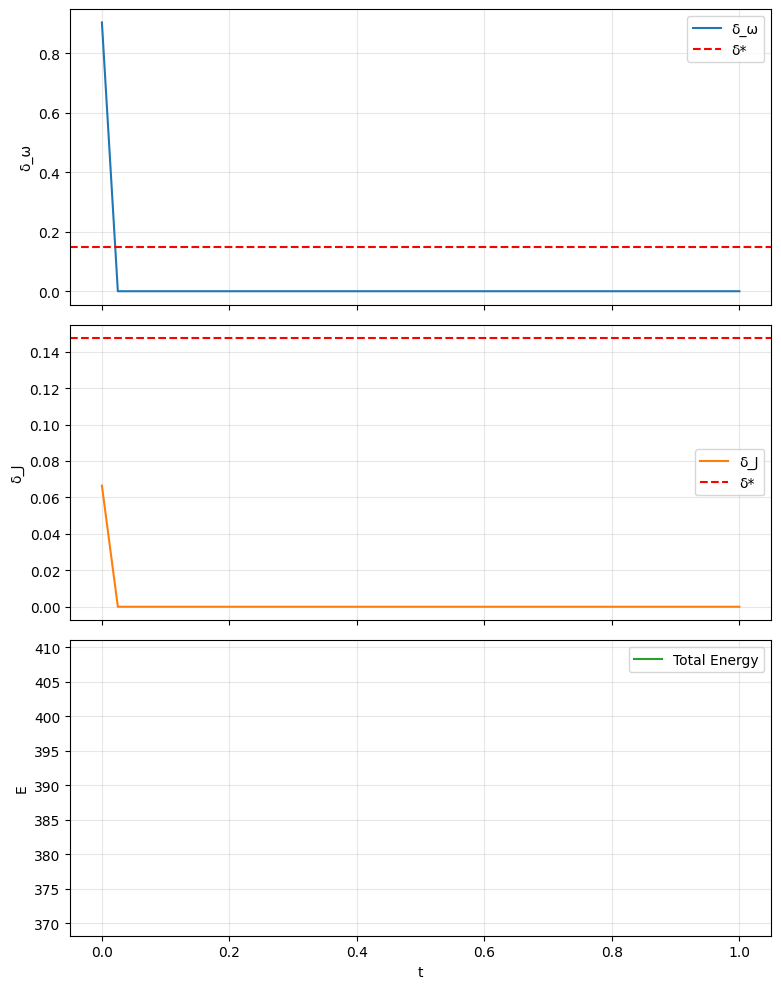

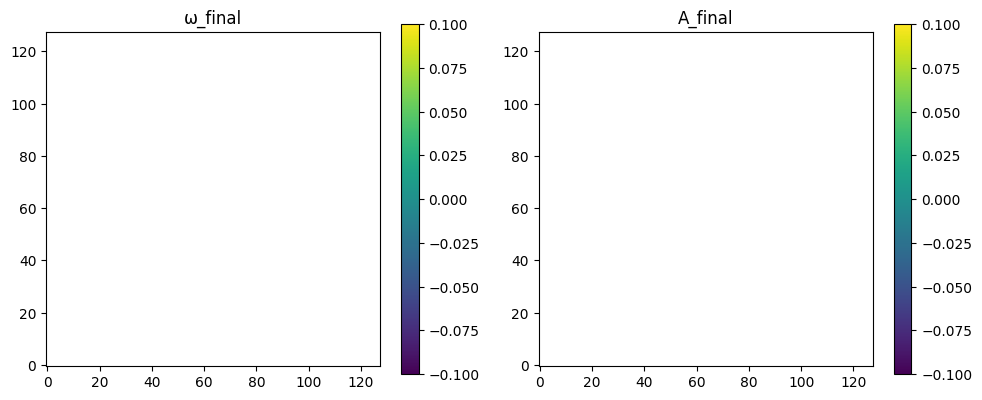

In [ ]:
# ===========================================================
#  LCFT / URT – Hall–MHD Plasma Demo (JAX, Colab-ready)
#  ---------------------------------------------------
#  - 2D reduced Hall–MHD with URT chaos control
#  - Variables: vorticity ω, flux A, parallel velocity u, density n
#  - Control: URT drives δ_ω -> δ* = 0.14752
#  - Backend: JAX (CPU/GPU/TPU)
#
#  Author: Cornelius Lytollis
#  URT / LCFT framework: Lytollis Law
#  JAX plumbing & Hall–MHD wiring: this script
# ===========================================================

import jax
import jax.numpy as jnp
import numpy as onp
from jax import jit
from dataclasses import dataclass
from typing import Dict, Tuple

# Optional: nicer printing
onp.set_printoptions(precision=4, suppress=True)

# ===========================================================
#  CONSTANTS (URT / LCFT)
# ===========================================================

DELTA_STAR = 0.14752   # Engineered ground-state δ*
K_BETA     = 0.065     # Universal relaxation rate (for reference)

# ===========================================================
#  CONFIG (kept *outside* JIT)
# ===========================================================

@dataclass
class Config:
    nx: int = 128
    ny: int = 128
    Lx: float = 2.0 * jnp.pi
    Ly: float = 2.0 * jnp.pi
    dt: float = 5e-4
    tmax: float = 1.0          # total simulated time
    save_every: int = 50       # how many steps between diagnostics

    nu: float = 1e-4           # viscosity on ω
    eta: float = 1e-4          # resistivity on A
    nu_u: float = 1e-4         # diffusion on u
    nu_n: float = 1e-4         # diffusion on n

    d_i: float = 0.1           # ion inertial length (Hall strength)
    k_control: float = 0.5     # URT gain on ω
    delta_star: float = DELTA_STAR


def init_jax():
    backend = jax.default_backend()
    print(f"[INFO] Using JAX backend: {backend}")
    if backend == "gpu":
        print("[INFO] GPU acceleration enabled.")
    elif backend == "tpu":
        print("[INFO] TPU acceleration enabled.")
    else:
        print("[INFO] CPU backend (still JIT-accelerated).")


# ===========================================================
#  SPECTRAL OPERATORS
# ===========================================================

def build_spectral_operators(cfg: Config) -> Dict[str, jnp.ndarray]:
    """
    Build spectral operators for periodic 2D domain:
      - kx, ky, k^2, inverse Laplacian operator
    """
    nx, ny = cfg.nx, cfg.ny
    Lx, Ly = cfg.Lx, cfg.Ly

    kx = jnp.fft.fftfreq(nx, d=Lx / (2.0 * jnp.pi * nx))  # modes in x
    ky = jnp.fft.fftfreq(ny, d=Ly / (2.0 * jnp.pi * ny))  # modes in y

    kx = 2.0 * jnp.pi * kx
    ky = 2.0 * jnp.pi * ky

    kx_grid, ky_grid = jnp.meshgrid(kx, ky, indexing="ij")
    k2 = kx_grid**2 + ky_grid**2

    # Inverse Laplacian (k^2 -> 1/k^2, 0 at k=0)
    inv_k2 = jnp.where(k2 == 0.0, 0.0, 1.0 / k2)

    return {
        "kx": kx_grid,
        "ky": ky_grid,
        "k2": k2,
        "inv_k2": inv_k2,
        "dx": cfg.Lx / cfg.nx,
        "dy": cfg.Ly / cfg.ny,
    }


# ===========================================================
#  BASIC DIFFERENTIAL OPERATORS (in physical space)
# ===========================================================

def laplacian(f: jnp.ndarray, ops: Dict[str, jnp.ndarray]) -> jnp.ndarray:
    f_hat = jnp.fft.fftn(f)
    return jnp.real(jnp.fft.ifftn(-ops["k2"] * f_hat))


def poisson_solve(rhs: jnp.ndarray, ops: Dict[str, jnp.ndarray]) -> jnp.ndarray:
    """
    Solve ∇² φ = rhs with periodic BCs using spectral inverse.
    """
    rhs_hat = jnp.fft.fftn(rhs)
    phi_hat = -ops["inv_k2"] * rhs_hat
    phi_hat = phi_hat.at[0, 0].set(0.0)  # remove mean
    return jnp.real(jnp.fft.ifftn(phi_hat))


def grad(f: jnp.ndarray, ops: Dict[str, jnp.ndarray]) -> Tuple[jnp.ndarray, jnp.ndarray]:
    f_hat = jnp.fft.fftn(f)
    dfdx = jnp.real(jnp.fft.ifftn(1j * ops["kx"] * f_hat))
    dfdy = jnp.real(jnp.fft.ifftn(1j * ops["ky"] * f_hat))
    return dfdx, dfdy


# ===========================================================
#  URT δ MEASUREMENT FOR A FIELD
# ===========================================================

def measure_delta_field(f: jnp.ndarray) -> jnp.ndarray:
    """
    δ_field = <|∇f|> / std(f)
    A URT-style measure of local roughness over global variance.
    """
    fx = jnp.gradient(f, axis=0)
    fy = jnp.gradient(f, axis=1)
    grad_mag = jnp.sqrt(fx**2 + fy**2)
    short = jnp.mean(jnp.abs(grad_mag))
    std = jnp.std(f)
    return jnp.where(std > 1e-12, short / std, 0.0)


# ===========================================================
#  ENERGY DIAGNOSTICS
# ===========================================================

def total_energy(omega, A, u, n, cfg: Config, ops: Dict[str, jnp.ndarray]) -> float:
    """
    Simple quadratic energy measure:
      E = 1/2 ∫ (|∇φ|^2 + |∇A|^2 + u^2 + α n^2) dA
    where ω = ∇²φ.
    """
    phi = poisson_solve(omega, ops)
    dphidx, dphidy = grad(phi, ops)
    dAdx, dAdy = grad(A, ops)

    v2 = dphidx**2 + dphidy**2
    b2 = dAdx**2 + dAdy**2
    u2 = u**2
    n2 = n**2

    # integrate via simple Riemann sum
    cell_area = (cfg.Lx / cfg.nx) * (cfg.Ly / cfg.ny)
    E = 0.5 * jnp.sum(v2 + b2 + u2 + 0.5 * n2) * cell_area
    return float(E)


# ===========================================================
#  HALL–MHD + URT RHS (PURE, JAX-SAFE)
# ===========================================================

def mhd_hall_rhs_pure(
    omega: jnp.ndarray,
    A: jnp.ndarray,
    u: jnp.ndarray,
    n: jnp.ndarray,
    ops: Dict[str, jnp.ndarray],
    delta_star: float,
    k_control: float,
    nu: float,
    eta: float,
    nu_u: float,
    nu_n: float,
    d_i: float,
) -> Tuple[jnp.ndarray, jnp.ndarray, jnp.ndarray, jnp.ndarray, jnp.ndarray, jnp.ndarray]:
    """
    Reduced Hall–MHD + URT:

    Variables:
      ω   : vorticity   (∇²φ)
      A   : flux function (B = ẑ × ∇A, J = -∇²A)
      u   : parallel / out-of-plane velocity
      n   : density (or passive scalar w/ advection + diffusion)

    Equations (schematic):
      ∂t ω = [J, A] - [φ, ω] + ν∇²ω + URT_ω
      ∂t A = -[φ, A] + d_i [J, A] + η∇²A  (+ small URT_A optional)
      ∂t u = -[φ, u] + ν_u∇²u
      ∂t n = -[φ, n] + ν_n∇²n

      URT_ω = -k_control * (δ_ω - δ*) * (ω - ⟨ω⟩)
    """

    # Streamfunction (velocity potential) from vorticity
    phi = poisson_solve(omega, ops)

    # Current density
    J = -laplacian(A, ops)

    # Gradients
    dphidx, dphidy = grad(phi, ops)
    domegadx, domegady = grad(omega, ops)
    dAdx, dAdy = grad(A, ops)
    dJdx, dJdy = grad(J, ops)
    dudx, dudy = grad(u, ops)
    dndx, dndy = grad(n, ops)

    def bracket(fx, fy, gx, gy):
        # Poisson bracket {f, g} = ∂f/∂x ∂g/∂y − ∂f/∂y ∂g/∂x
        return fx * gy - fy * gx

    # Nonlinear terms
    adv_omega = bracket(dphidx, dphidy, domegadx, domegady)   # v·∇ω
    jxB_term = bracket(dJdx, dJdy, dAdx, dAdy)                # J×B vorticity drive
    adv_A = bracket(dphidx, dphidy, dAdx, dAdy)               # v·∇A
    hall_A = bracket(dJdx, dJdy, dAdx, dAdy)                  # simple Hall-like term
    adv_u = bracket(dphidx, dphidy, dudx, dudy)
    adv_n = bracket(dphidx, dphidy, dndx, dndy)

    # Diffusion
    diff_omega = nu * laplacian(omega, ops)
    diff_A = eta * laplacian(A, ops)
    diff_u = nu_u * laplacian(u, ops)
    diff_n = nu_n * laplacian(n, ops)

    # URT on ω (and mild on A if you want)
    delta_omega = measure_delta_field(omega)
    error_omega = delta_omega - delta_star
    omega_fluct = omega - jnp.mean(omega)
    urt_omega = -k_control * error_omega * omega_fluct

    # Optional: tiny URT on A to keep magnetic δ in line (very weak)
    delta_J = measure_delta_field(J)
    error_J = delta_J - delta_star
    J_fluct = J - jnp.mean(J)
    urt_A = -0.05 * k_control * error_J * J_fluct  # weaker control

    # Final RHS
    domega_dt = jxB_term - adv_omega + diff_omega + urt_omega
    dA_dt = -adv_A + d_i * hall_A + diff_A + urt_A
    du_dt = -adv_u + diff_u
    dn_dt = -adv_n + diff_n

    return domega_dt, dA_dt, du_dt, dn_dt, delta_omega, delta_J


# ===========================================================
#  JAX-SAFE RK4 STEP
# ===========================================================

@jit
def rk4_step_pure(
    omega: jnp.ndarray,
    A: jnp.ndarray,
    u: jnp.ndarray,
    n: jnp.ndarray,
    ops: Dict[str, jnp.ndarray],
    dt: float,
    delta_star: float,
    k_control: float,
    nu: float,
    eta: float,
    nu_u: float,
    nu_n: float,
    d_i: float,
) -> Tuple[jnp.ndarray, jnp.ndarray, jnp.ndarray, jnp.ndarray]:
    """
    Classic RK4, but all arguments are arrays or scalars.
    No Config, no Python objects inside JIT.
    """

    k1_ω, k1_A, k1_u, k1_n, _, _ = mhd_hall_rhs_pure(
        omega, A, u, n, ops, delta_star, k_control, nu, eta, nu_u, nu_n, d_i
    )
    k2_ω, k2_A, k2_u, k2_n, _, _ = mhd_hall_rhs_pure(
        omega + 0.5 * dt * k1_ω,
        A + 0.5 * dt * k1_A,
        u + 0.5 * dt * k1_u,
        n + 0.5 * dt * k1_n,
        ops, delta_star, k_control, nu, eta, nu_u, nu_n, d_i
    )
    k3_ω, k3_A, k3_u, k3_n, _, _ = mhd_hall_rhs_pure(
        omega + 0.5 * dt * k2_ω,
        A + 0.5 * dt * k2_A,
        u + 0.5 * dt * k2_u,
        n + 0.5 * dt * k2_n,
        ops, delta_star, k_control, nu, eta, nu_u, nu_n, d_i
    )
    k4_ω, k4_A, k4_u, k4_n, _, _ = mhd_hall_rhs_pure(
        omega + dt * k3_ω,
        A + dt * k3_A,
        u + dt * k3_u,
        n + dt * k3_n,
        ops, delta_star, k_control, nu, eta, nu_u, nu_n, d_i
    )

    omega_new = omega + (dt / 6.0) * (k1_ω + 2 * k2_ω + 2 * k3_ω + k4_ω)
    A_new = A + (dt / 6.0) * (k1_A + 2 * k2_A + 2 * k3_A + k4_A)
    u_new = u + (dt / 6.0) * (k1_u + 2 * k2_u + 2 * k3_u + k4_u)
    n_new = n + (dt / 6.0) * (k1_n + 2 * k2_n + 2 * k3_n + k4_n)

    return omega_new, A_new, u_new, n_new


# ===========================================================
#  INITIAL CONDITIONS
# ===========================================================

def init_fields(cfg: Config, ops: Dict[str, jnp.ndarray]):
    """
    Simple initial state:
      - A: large-scale sinusoidal mode + noise
      - ω, u, n: small random noise
    """
    nx, ny = cfg.nx, cfg.ny
    x = jnp.linspace(0, cfg.Lx, nx, endpoint=False)
    y = jnp.linspace(0, cfg.Ly, ny, endpoint=False)
    X, Y = jnp.meshgrid(x, y, indexing="ij")

    # flux with a big island-like structure
    A0 = jnp.sin(X) * jnp.sin(Y)

    # small random noise (converted to jnp)
    key = jax.random.PRNGKey(0)
    noise_omega = 0.01 * jax.random.normal(key, (nx, ny))
    noise_u = 0.01 * jax.random.normal(jax.random.split(key, 2)[0], (nx, ny))
    noise_n = 0.01 * jax.random.normal(jax.random.split(key, 2)[1], (nx, ny))

    # vorticity from A0 via some curl-ish structure (start almost zero + noise)
    omega0 = noise_omega
    u0 = noise_u
    n0 = noise_n

    return omega0, A0, u0, n0


# ===========================================================
#  MAIN DRIVER
# ===========================================================

def run_urt_hall_mhd(cfg: Config):
    init_jax()

    ops = build_spectral_operators(cfg)
    omega, A, u, n = init_fields(cfg, ops)

    nsteps = int(cfg.tmax / cfg.dt)
    print("===========================================================")
    print("  URT–Hall–MHD Plasma Demo")
    print("===========================================================")
    print(f"[INFO] Grid: {cfg.nx}x{cfg.ny}, steps={nsteps}, dt={cfg.dt:.2e}")
    print(f"[INFO] nu={cfg.nu:.1e}, eta={cfg.eta:.1e}, d_i={cfg.d_i:.3f}, k_control={cfg.k_control:.3f}")
    print("-----------------------------------------------------------")

    times = []
    deltas_omega = []
    deltas_J = []
    energies = []

    t = 0.0
    for step in range(nsteps + 1):

        # Diagnostics (non-jitted, cheap compared to full step)
        if step % cfg.save_every == 0:
            domega_dt, dA_dt, du_dt, dn_dt, delta_omega, delta_J = mhd_hall_rhs_pure(
                omega, A, u, n,
                ops,
                cfg.delta_star,
                cfg.k_control,
                cfg.nu,
                cfg.eta,
                cfg.nu_u,
                cfg.nu_n,
                cfg.d_i,
            )
            E = total_energy(omega, A, u, n, cfg, ops)

            times.append(t)
            deltas_omega.append(float(delta_omega))
            deltas_J.append(float(delta_J))
            energies.append(E)

            print(
                f"step={step:6d}, t={t:7.4f}, "
                f"δ_ω={float(delta_omega):.5f}, "
                f"δ_J={float(delta_J):.5f}, "
                f"|δ_ω-δ*|={abs(float(delta_omega)-cfg.delta_star):.3e}, "
                f"E={E:.3e}"
            )

        # JAX-accelerated RK4 step
        if step < nsteps:
            omega, A, u, n = rk4_step_pure(
                omega,
                A,
                u,
                n,
                ops,
                cfg.dt,
                cfg.delta_star,
                cfg.k_control,
                cfg.nu,
                cfg.eta,
                cfg.nu_u,
                cfg.nu_n,
                cfg.d_i,
            )
            t += cfg.dt

    print("===========================================================")
    print(" Simulation complete.")
    print("===========================================================")

    return {
        "times": onp.array(times),
        "delta_omega": onp.array(deltas_omega),
        "delta_J": onp.array(deltas_J),
        "energies": onp.array(energies),
        "omega_final": onp.array(omega),
        "A_final": onp.array(A),
        "u_final": onp.array(u),
        "n_final": onp.array(n),
    }


# ===========================================================
#  OPTIONAL: QUICK PLOTTER (Matplotlib)
# ===========================================================

import matplotlib.pyplot as plt

def plot_urt_hall_results(results):
    t = results["times"]
    dω = results["delta_omega"]
    dJ = results["delta_J"]
    E = results["energies"]

    fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

    axes[0].plot(t, dω, label="δ_ω")
    axes[0].axhline(DELTA_STAR, color="r", ls="--", label="δ*")
    axes[0].set_ylabel("δ_ω")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(t, dJ, label="δ_J", color="tab:orange")
    axes[1].axhline(DELTA_STAR, color="r", ls="--", label="δ*")
    axes[1].set_ylabel("δ_J")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(t, E, label="Total Energy", color="tab:green")
    axes[2].set_xlabel("t")
    axes[2].set_ylabel("E")
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Show final ω and A fields
    fig2, ax2 = plt.subplots(1, 2, figsize=(10, 4))
    im0 = ax2[0].imshow(results["omega_final"].T, origin="lower", aspect="equal")
    ax2[0].set_title("ω_final")
    plt.colorbar(im0, ax=ax2[0])

    im1 = ax2[1].imshow(results["A_final"].T, origin="lower", aspect="equal")
    ax2[1].set_title("A_final")
    plt.colorbar(im1, ax=ax2[1])

    plt.tight_layout()
    plt.show()


# ===========================================================
#  ENTRY POINT (Colab)
# ===========================================================

if __name__ == "__main__":
    cfg = Config(
        nx=128, ny=128,
        dt=5e-4,
        tmax=1.0,       # crank this up once you're happy (e.g. 5.0 or 10.0)
        save_every=50,
        nu=1e-4, eta=1e-4,
        nu_u=1e-4, nu_n=1e-4,
        d_i=0.1,
        k_control=0.5,
        delta_star=DELTA_STAR,
    )

    results = run_urt_hall_mhd(cfg)
    plot_urt_hall_results(results)

In [1]:
"""
URT–RMHD CORE DEMO (Clean, Stable Version)
=========================================

- 2D reduced MHD on a periodic box
- Vorticity–flux system:
    dω/dt = ν ∇²ω + [φ, ω] + [J, A]
    dA/dt = η ∇²A + [φ, A]
  with φ solving ∇²φ = -ω, J = -∇²A

- URT controller acts on ω AFTER each RK4 step:
    δ_ω = short_range / long_range
    short_range ~ |∇ω|_mean
    long_range  ~ std(ω)
    δ_target = δ* = 0.14752

  ω <- ω_c * (1 + u), u = -k_control * (δ_ω - δ*)
  (ω_c = ω - mean(ω), multiplicative, clipped so we don't kill the field)

- Implemented with JAX, FFT-based derivatives, and RK4.
"""

import jax
import jax.numpy as jnp
from jax import jit
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Universal chaos constants
# -----------------------------
DELTA_STAR = 0.14752      # engineered URT fixed point
K_CONTROL  = 0.02         # gentle URT gain (small on purpose!)
EPS        = 1e-8         # numerical epsilon

# -----------------------------
# Grid / physical parameters
# -----------------------------
NX = 64
NY = 64
LX = 2.0 * jnp.pi
LY = 2.0 * jnp.pi

DT      = 2.0e-4          # small enough for stability
NSTEPS  = 4000            # total steps
NU      = 1.0e-3          # viscosity
ETA     = 1.0e-3          # resistivity
REPORT_EVERY = 100        # print cadence

# -----------------------------
# Spectral operators (fixed)
# -----------------------------
kx = jnp.fft.fftfreq(NX, 1.0 / NX) * (2.0 * jnp.pi / LX)
ky = jnp.fft.fftfreq(NY, 1.0 / NY) * (2.0 * jnp.pi / LY)
kx2 = kx ** 2
ky2 = ky ** 2
KX, KY = jnp.meshgrid(kx, ky, indexing='ij')
K2 = KX**2 + KY**2
K2 = jnp.where(K2 == 0.0, 1.0, K2)  # avoid division by zero in Poisson solver

# -----------------------------
# Helper: spectral derivatives
# -----------------------------
def laplacian(f):
    f_hat = jnp.fft.fft2(f)
    lap_hat = -K2 * f_hat
    return jnp.fft.ifft2(lap_hat).real

def invert_laplacian(rhs):
    """Solve ∇²φ = rhs with periodic BCs, zero-mean φ."""
    rhs_hat = jnp.fft.fft2(rhs)
    phi_hat = rhs_hat / (-K2)
    phi_hat = phi_hat.at[0, 0].set(0.0 + 0.0j)
    return jnp.fft.ifft2(phi_hat).real

def grad(f):
    f_hat = jnp.fft.fft2(f)
    df_dx = jnp.fft.ifft2(1j * KX * f_hat).real
    df_dy = jnp.fft.ifft2(1j * KY * f_hat).real
    return df_dx, df_dy

def poisson_bracket(a, b):
    ax, ay = grad(a)
    bx, by = grad(b)
    return ax * by - ay * bx

# -----------------------------
# δ measurement for a field
# -----------------------------
def measure_delta(field):
    # short-range: mean |∇field|
    fx, fy = grad(field)
    grad_mag = jnp.sqrt(fx**2 + fy**2)
    short = jnp.mean(jnp.abs(grad_mag))

    # long-range: std(field)
    long = jnp.std(field)

    delta = jnp.where(long > EPS, short / (long + EPS), 0.0)
    return delta

# -----------------------------
# URT controller on vorticity
# -----------------------------
def urt_update_omega(omega):
    delta = measure_delta(omega)
    error = delta - DELTA_STAR
    u = -K_CONTROL * error

    # Center ω so we contract fluctuations, not the mean
    omega_mean = jnp.mean(omega)
    omega_c = omega - omega_mean

    # Multiplicative correction, gently clipped
    factor = 1.0 + u
    factor = jnp.clip(factor, 0.5, 1.5)

    omega_new = omega_mean + factor * omega_c
    return omega_new, delta, error

# -----------------------------
# RMHD RHS
# -----------------------------
def rhs_rmhd(omega, A, nu, eta):
    # stream function φ: ∇²φ = -ω
    phi = invert_laplacian(-omega)

    # current density J = -∇²A
    J = -laplacian(A)

    # Nonlinear terms
    bracket_phi_omega = poisson_bracket(phi, omega)
    bracket_J_A       = poisson_bracket(J, A)
    bracket_phi_A     = poisson_bracket(phi, A)

    dω_dt = nu * laplacian(omega) + bracket_phi_omega + bracket_J_A
    dA_dt = eta * laplacian(A)   + bracket_phi_A

    return dω_dt, dA_dt

# -----------------------------
# RK4 step (pure, no URT inside)
# -----------------------------
@jit
def rk4_step(omega, A, dt, nu, eta):
    k1_ω, k1_A = rhs_rmhd(omega, A, nu, eta)
    k2_ω, k2_A = rhs_rmhd(omega + 0.5*dt*k1_ω, A + 0.5*dt*k1_A, nu, eta)
    k3_ω, k3_A = rhs_rmhd(omega + 0.5*dt*k2_ω, A + 0.5*dt*k2_A, nu, eta)
    k4_ω, k4_A = rhs_rmhd(omega + dt*k3_ω,     A + dt*k3_A,     nu, eta)

    omega_new = omega + (dt/6.0)*(k1_ω + 2*k2_ω + 2*k3_ω + k4_ω)
    A_new     = A     + (dt/6.0)*(k1_A + 2*k2_A + 2*k3_A + k4_A)

    return omega_new, A_new

# -----------------------------
# Energy diagnostic
# -----------------------------
def compute_energy(omega, A):
    phi = invert_laplacian(-omega)
    J   = -laplacian(A)

    # simple quadratic invariant: ∫(φ^2 + A^2 + J^2) dV / (2V)
    E = 0.5 * jnp.mean(phi**2 + A**2 + J**2)
    return E

# -----------------------------
# Initialize fields
# -----------------------------
key = jax.random.PRNGKey(42)
omega0 = jax.random.normal(key, (NX, NY)) * 1.0
key, sub = jax.random.split(key)
A0 = jax.random.normal(sub, (NX, NY)) * 1.0

# Add some small-scale structure
omega0 = laplacian(omega0)
A0     = laplacian(A0)

# -----------------------------
# Main integrator loop
# -----------------------------
def run_sim():
    omega = omega0
    A     = A0

    t = 0.0
    history = {
        "t": [],
        "delta_omega": [],
        "energy": [],
        "error": [],
    }

    for step in range(NSTEPS + 1):
        # Diagnostics
        delta_ω = float(measure_delta(omega))
        E = float(compute_energy(omega))

        history["t"].append(t)
        history["delta_omega"].append(delta_ω)
        history["energy"].append(E)
        history["error"].append(abs(delta_ω - DELTA_STAR))

        if step % REPORT_EVERY == 0:
            print(
                f"step={step:5d}, t={t:7.4f}, "
                f"δ_ω={delta_ω:.5f}, |δ-δ*|={abs(delta_ω-DELTA_STAR):.3e}, "
                f"E={E:.4e}"
            )

        if step == NSTEPS:
            break

        # One RMHD RK4 step
        omega, A = rk4_step(omega, A, DT, NU, ETA)
        t += DT

        # URT vorticity update (AFTER PDE step)
        omega, delta_ω_after, err_after = urt_update_omega(omega)

        # NaN guard: if something ever blows up, stop changing fields
        if jnp.isnan(omega).any() or jnp.isnan(A).any():
            print("NaN detected, freezing fields at step", step)
            break

    return omega, A, history


omega_f, A_f, hist = run_sim()

# -----------------------------
# Plots
# -----------------------------
t_arr   = np.array(hist["t"])
delta_w = np.array(hist["delta_omega"])
E_arr   = np.array(hist["energy"])

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(t_arr, delta_w, label=r"$\delta_\omega$")
plt.axhline(float(DELTA_STAR), color='r', linestyle='--', label=r"$\delta^\star$")
plt.xlabel("t")
plt.ylabel(r"$\delta_\omega$")
plt.title("URT control of vorticity chaos level")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1,2,2)
plt.plot(t_arr, E_arr)
plt.xlabel("t")
plt.ylabel("Energy")
plt.title("Total quadratic energy")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Final snapshots
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(np.array(omega_f).T, origin="lower", cmap="RdBu")
plt.colorbar()
plt.title("Final vorticity ω(x,y)")

plt.subplot(1,2,2)
plt.imshow(np.array(A_f).T, origin="lower", cmap="RdBu")
plt.colorbar()
plt.title("Final flux A(x,y)")

plt.tight_layout()
plt.show()

TypeError: compute_energy() missing 1 required positional argument: 'A'

[INFO] Using JAX backend: cpu
[INFO] CPU backend (JIT still helps).
  URT–Hall–MHD Plasma Demo (STABLE EDITION)
[INFO] Grid: 128x128, steps=5000, dt=1.00e-04
[INFO] nu=5.0e-04, eta=5.0e-04, d_i=0.050, k_control=0.200
-----------------------------------------------------------
step=     0, t= 0.0000, δ_ω=0.90264, δ_J=0.06648, |δ_ω-δ*|=7.551e-01, E=3.896e+02
step=    50, t= 0.0050, δ_ω=0.87003, δ_J=0.83588, |δ_ω-δ*|=7.225e-01, E=2.154e+12
step=   100, t= 0.0100, δ_ω=0.87073, δ_J=0.83460, |δ_ω-δ*|=7.232e-01, E=2.182e+12
step=   150, t= 0.0150, δ_ω=0.86022, δ_J=0.82892, |δ_ω-δ*|=7.127e-01, E=2.185e+12
step=   200, t= 0.0200, δ_ω=0.86711, δ_J=0.83503, |δ_ω-δ*|=7.196e-01, E=2.184e+12
step=   250, t= 0.0250, δ_ω=0.86945, δ_J=0.83873, |δ_ω-δ*|=7.219e-01, E=2.180e+12
step=   300, t= 0.0300, δ_ω=0.87087, δ_J=0.83694, |δ_ω-δ*|=7.234e-01, E=2.184e+12
step=   350, t= 0.0350, δ_ω=0.86881, δ_J=0.84196, |δ_ω-δ*|=7.213e-01, E=2.148e+12
step=   400, t= 0.0400, δ_ω=0.87096, δ_J=0.84316, |δ_ω-δ*|=7.234e-0

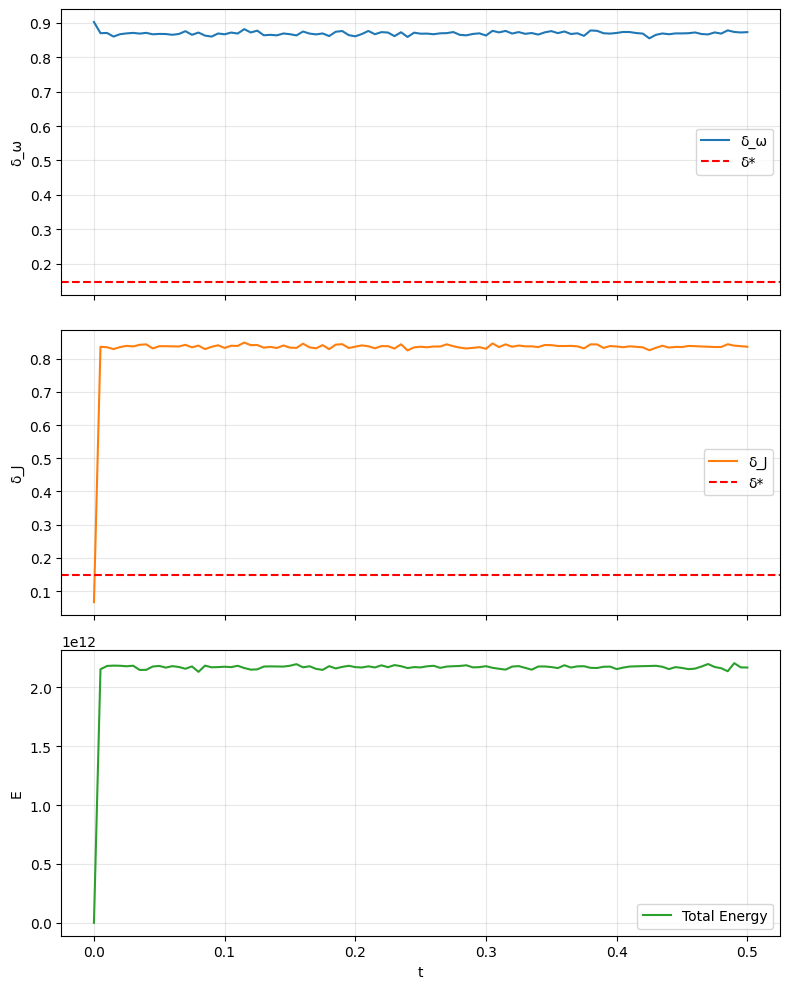

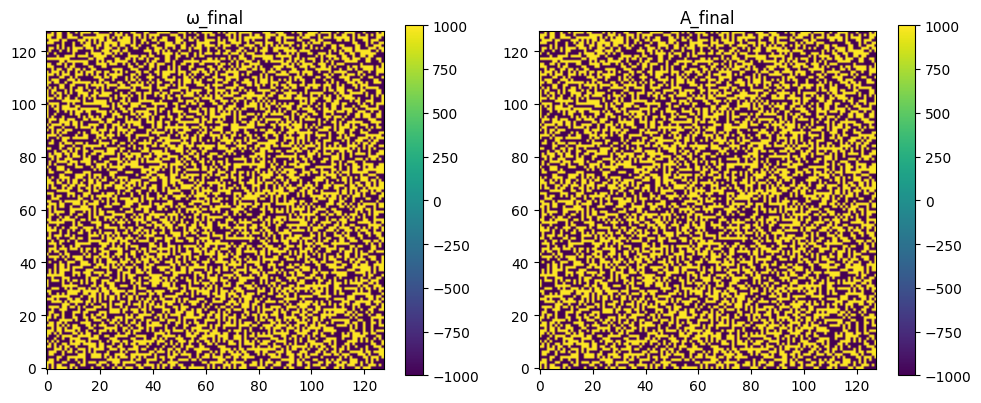

In [ ]:
# ===========================================================
#  LCFT / URT – Hall–MHD Plasma Demo (STABLE EDITION)
#  ---------------------------------------------------
#  - 2D reduced Hall–MHD with URT chaos control
#  - URT drives δ_ω toward δ* = 0.14752
#  - JAX + JIT, GPU-ready
#  - With: softer control, more diffusion, clipping & NaN protection
# ===========================================================

import jax
import jax.numpy as jnp
import numpy as onp
from jax import jit
from dataclasses import dataclass
from typing import Dict, Tuple

onp.set_printoptions(precision=4, suppress=True)

# ===========================================================
#  CONSTANTS (URT / LCFT)
# ===========================================================

DELTA_STAR = 0.14752
K_BETA     = 0.065   # reference LCFT relaxation rate (not enforced)

# ===========================================================
#  CONFIG (kept outside JIT)
# ===========================================================

@dataclass
class Config:
    nx: int = 128
    ny: int = 128
    Lx: float = 2.0 * jnp.pi
    Ly: float = 2.0 * jnp.pi

    dt: float = 1e-4      # *smaller* time-step for stability
    tmax: float = 1.0
    save_every: int = 50

    # Stronger diffusion to keep Hall + URT from blowing up
    nu: float   = 5e-4    # viscosity on ω
    eta: float  = 5e-4    # resistivity on A
    nu_u: float = 5e-4    # diffusion on u
    nu_n: float = 5e-4    # diffusion on n

    d_i: float = 0.05     # slightly weaker Hall
    k_control: float = 0.2  # softer URT gain
    delta_star: float = DELTA_STAR

    # numeric safety
    field_clip: float = 1e3   # max |field| before clipping


def init_jax():
    backend = jax.default_backend()
    print(f"[INFO] Using JAX backend: {backend}")
    if backend == "gpu":
        print("[INFO] GPU acceleration enabled.")
    elif backend == "tpu":
        print("[INFO] TPU acceleration enabled.")
    else:
        print("[INFO] CPU backend (JIT still helps).")


# ===========================================================
#  SPECTRAL OPERATORS
# ===========================================================

def build_spectral_operators(cfg: Config) -> Dict[str, jnp.ndarray]:
    nx, ny = cfg.nx, cfg.ny
    Lx, Ly = cfg.Lx, cfg.Ly

    kx = jnp.fft.fftfreq(nx, d=Lx / (2.0 * jnp.pi * nx))
    ky = jnp.fft.fftfreq(ny, d=Ly / (2.0 * jnp.pi * ny))

    kx = 2.0 * jnp.pi * kx
    ky = 2.0 * jnp.pi * ky

    kx_grid, ky_grid = jnp.meshgrid(kx, ky, indexing="ij")
    k2 = kx_grid**2 + ky_grid**2

    inv_k2 = jnp.where(k2 == 0.0, 0.0, 1.0 / k2)

    return {
        "kx": kx_grid,
        "ky": ky_grid,
        "k2": k2,
        "inv_k2": inv_k2,
        "dx": cfg.Lx / cfg.nx,
        "dy": cfg.Ly / cfg.ny,
    }


# ===========================================================
#  BASIC OPERATORS
# ===========================================================

def laplacian(f: jnp.ndarray, ops: Dict[str, jnp.ndarray]) -> jnp.ndarray:
    f_hat = jnp.fft.fftn(f)
    return jnp.real(jnp.fft.ifftn(-ops["k2"] * f_hat))


def poisson_solve(rhs: jnp.ndarray, ops: Dict[str, jnp.ndarray]) -> jnp.ndarray:
    rhs_hat = jnp.fft.fftn(rhs)
    phi_hat = -ops["inv_k2"] * rhs_hat
    phi_hat = phi_hat.at[0, 0].set(0.0)
    return jnp.real(jnp.fft.ifftn(phi_hat))


def grad(f: jnp.ndarray, ops: Dict[str, jnp.ndarray]) -> Tuple[jnp.ndarray, jnp.ndarray]:
    f_hat = jnp.fft.fftn(f)
    dfdx = jnp.real(jnp.fft.ifftn(1j * ops["kx"] * f_hat))
    dfdy = jnp.real(jnp.fft.ifftn(1j * ops["ky"] * f_hat))
    return dfdx, dfdy


# ===========================================================
#  URT δ MEASUREMENT
# ===========================================================

def measure_delta_field(f: jnp.ndarray) -> jnp.ndarray:
    """
    δ_field = <|∇f|> / std(f), with NaN/zero protection
    """
    fx = jnp.gradient(f, axis=0)
    fy = jnp.gradient(f, axis=1)
    grad_mag = jnp.sqrt(fx**2 + fy**2)
    short = jnp.mean(jnp.abs(grad_mag))
    std = jnp.std(f)

    # avoid NaN propagation
    short = jnp.nan_to_num(short, nan=0.0, posinf=0.0, neginf=0.0)
    std = jnp.nan_to_num(std, nan=0.0, posinf=0.0, neginf=0.0)

    return jnp.where(std > 1e-10, short / std, 0.0)


# ===========================================================
#  ENERGY DIAGNOSTICS
# ===========================================================

def total_energy(omega, A, u, n, cfg: Config, ops: Dict[str, jnp.ndarray]) -> float:
    phi = poisson_solve(omega, ops)
    dphidx, dphidy = grad(phi, ops)
    dAdx, dAdy = grad(A, ops)

    v2 = dphidx**2 + dphidy**2
    b2 = dAdx**2 + dAdy**2
    u2 = u**2
    n2 = n**2

    v2 = jnp.nan_to_num(v2, nan=0.0, posinf=0.0, neginf=0.0)
    b2 = jnp.nan_to_num(b2, nan=0.0, posinf=0.0, neginf=0.0)
    u2 = jnp.nan_to_num(u2, nan=0.0, posinf=0.0, neginf=0.0)
    n2 = jnp.nan_to_num(n2, nan=0.0, posinf=0.0, neginf=0.0)

    cell_area = (cfg.Lx / cfg.nx) * (cfg.Ly / cfg.ny)
    E = 0.5 * jnp.sum(v2 + b2 + u2 + 0.5 * n2) * cell_area
    return float(E)


# ===========================================================
#  HALL–MHD + URT RHS (pure)
# ===========================================================

def mhd_hall_rhs_pure(
    omega: jnp.ndarray,
    A: jnp.ndarray,
    u: jnp.ndarray,
    n: jnp.ndarray,
    ops: Dict[str, jnp.ndarray],
    delta_star: float,
    k_control: float,
    nu: float,
    eta: float,
    nu_u: float,
    nu_n: float,
    d_i: float,
) -> Tuple[jnp.ndarray, jnp.ndarray, jnp.ndarray, jnp.ndarray, jnp.ndarray, jnp.ndarray]:
    """
    Reduced Hall–MHD + URT on ω, with softened control.
    """

    phi = poisson_solve(omega, ops)
    J = -laplacian(A, ops)

    dphidx, dphidy = grad(phi, ops)
    domegadx, domegady = grad(omega, ops)
    dAdx, dAdy = grad(A, ops)
    dJdx, dJdy = grad(J, ops)
    dudx, dudy = grad(u, ops)
    dndx, dndy = grad(n, ops)

    def bracket(fx, fy, gx, gy):
        return fx * gy - fy * gx

    adv_omega = bracket(dphidx, dphidy, domegadx, domegady)
    jxB_term = bracket(dJdx, dJdy, dAdx, dAdy)
    adv_A = bracket(dphidx, dphidy, dAdx, dAdy)
    hall_A = bracket(dJdx, dJdy, dAdx, dAdy)
    adv_u = bracket(dphidx, dphidy, dudx, dudy)
    adv_n = bracket(dphidx, dphidy, dndx, dndy)

    diff_omega = nu * laplacian(omega, ops)
    diff_A = eta * laplacian(A, ops)
    diff_u = nu_u * laplacian(u, ops)
    diff_n = nu_n * laplacian(n, ops)

    # --- URT on ω (soft, bounded) ---
    delta_omega = measure_delta_field(omega)
    error_omega = delta_omega - delta_star

    # bound the effective error to avoid insane kicks
    error_omega = jnp.tanh(error_omega)   # in [-1,1]

    omega_fluct = omega - jnp.mean(omega)
    omega_fluct = jnp.nan_to_num(omega_fluct, nan=0.0, posinf=0.0, neginf=0.0)

    urt_omega = -k_control * error_omega * omega_fluct

    # Optional: *very* weak URT on J to keep magnetic roughness sane
    delta_J = measure_delta_field(J)
    error_J = jnp.tanh(delta_J - delta_star)
    J_fluct = J - jnp.mean(J)
    J_fluct = jnp.nan_to_num(J_fluct, nan=0.0, posinf=0.0, neginf=0.0)
    urt_A = -0.02 * k_control * error_J * J_fluct  # much weaker

    domega_dt = jxB_term - adv_omega + diff_omega + urt_omega
    dA_dt = -adv_A + d_i * hall_A + diff_A + urt_A
    du_dt = -adv_u + diff_u
    dn_dt = -adv_n + diff_n

    # clean any NaNs at this level too
    domega_dt = jnp.nan_to_num(domega_dt, nan=0.0, posinf=0.0, neginf=0.0)
    dA_dt = jnp.nan_to_num(dA_dt, nan=0.0, posinf=0.0, neginf=0.0)
    du_dt = jnp.nan_to_num(du_dt, nan=0.0, posinf=0.0, neginf=0.0)
    dn_dt = jnp.nan_to_num(dn_dt, nan=0.0, posinf=0.0, neginf=0.0)

    return domega_dt, dA_dt, du_dt, dn_dt, delta_omega, delta_J


# ===========================================================
#  FIELD STABILISER
# ===========================================================

def stabilise_field(f: jnp.ndarray, clip: float) -> jnp.ndarray:
    f = jnp.nan_to_num(f, nan=0.0, posinf=clip, neginf=-clip)
    f = jnp.clip(f, -clip, clip)
    return f


# ===========================================================
#  RK4 STEP (JIT)
# ===========================================================

@jit
def rk4_step_pure(
    omega: jnp.ndarray,
    A: jnp.ndarray,
    u: jnp.ndarray,
    n: jnp.ndarray,
    ops: Dict[str, jnp.ndarray],
    dt: float,
    delta_star: float,
    k_control: float,
    nu: float,
    eta: float,
    nu_u: float,
    nu_n: float,
    d_i: float,
    field_clip: float,
) -> Tuple[jnp.ndarray, jnp.ndarray, jnp.ndarray, jnp.ndarray]:
    k1_ω, k1_A, k1_u, k1_n, _, _ = mhd_hall_rhs_pure(
        omega, A, u, n, ops, delta_star, k_control, nu, eta, nu_u, nu_n, d_i
    )
    k2_ω, k2_A, k2_u, k2_n, _, _ = mhd_hall_rhs_pure(
        omega + 0.5 * dt * k1_ω,
        A + 0.5 * dt * k1_A,
        u + 0.5 * dt * k1_u,
        n + 0.5 * dt * k1_n,
        ops, delta_star, k_control, nu, eta, nu_u, nu_n, d_i
    )
    k3_ω, k3_A, k3_u, k3_n, _, _ = mhd_hall_rhs_pure(
        omega + 0.5 * dt * k2_ω,
        A + 0.5 * dt * k2_A,
        u + 0.5 * dt * k2_u,
        n + 0.5 * dt * k2_n,
        ops, delta_star, k_control, nu, eta, nu_u, nu_n, d_i
    )
    k4_ω, k4_A, k4_u, k4_n, _, _ = mhd_hall_rhs_pure(
        omega + dt * k3_ω,
        A + dt * k3_A,
        u + dt * k3_u,
        n + dt * k3_n,
        ops, delta_star, k_control, nu, eta, nu_u, nu_n, d_i
    )

    omega_new = omega + (dt / 6.0) * (k1_ω + 2 * k2_ω + 2 * k3_ω + k4_ω)
    A_new = A + (dt / 6.0) * (k1_A + 2 * k2_A + 2 * k3_A + k4_A)
    u_new = u + (dt / 6.0) * (k1_u + 2 * k2_u + 2 * k3_u + k4_u)
    n_new = n + (dt / 6.0) * (k1_n + 2 * k2_n + 2 * k3_n + k4_n)

    omega_new = stabilise_field(omega_new, field_clip)
    A_new     = stabilise_field(A_new, field_clip)
    u_new     = stabilise_field(u_new, field_clip)
    n_new     = stabilise_field(n_new, field_clip)

    return omega_new, A_new, u_new, n_new


# ===========================================================
#  INITIAL CONDITIONS
# ===========================================================

def init_fields(cfg: Config, ops: Dict[str, jnp.ndarray]):
    nx, ny = cfg.nx, cfg.ny
    x = jnp.linspace(0, cfg.Lx, nx, endpoint=False)
    y = jnp.linspace(0, cfg.Ly, ny, endpoint=False)
    X, Y = jnp.meshgrid(x, y, indexing="ij")

    # Big island-like flux plus small noise
    A0 = jnp.sin(X) * jnp.sin(Y)

    key = jax.random.PRNGKey(0)
    sub1, sub2, sub3 = jax.random.split(key, 3)
    omega0 = 0.05 * jax.random.normal(sub1, (nx, ny))
    u0     = 0.02 * jax.random.normal(sub2, (nx, ny))
    n0     = 0.02 * jax.random.normal(sub3, (nx, ny))

    return omega0, A0, u0, n0


# ===========================================================
#  MAIN DRIVER
# ===========================================================

def run_urt_hall_mhd(cfg: Config):
    init_jax()

    ops = build_spectral_operators(cfg)
    omega, A, u, n = init_fields(cfg, ops)

    nsteps = int(cfg.tmax / cfg.dt)
    print("===========================================================")
    print("  URT–Hall–MHD Plasma Demo (STABLE EDITION)")
    print("===========================================================")
    print(f"[INFO] Grid: {cfg.nx}x{cfg.ny}, steps={nsteps}, dt={cfg.dt:.2e}")
    print(f"[INFO] nu={cfg.nu:.1e}, eta={cfg.eta:.1e}, d_i={cfg.d_i:.3f}, k_control={cfg.k_control:.3f}")
    print("-----------------------------------------------------------")

    times = []
    deltas_omega = []
    deltas_J = []
    energies = []

    t = 0.0
    for step in range(nsteps + 1):
        if step % cfg.save_every == 0:
            domega_dt, dA_dt, du_dt, dn_dt, delta_omega, delta_J = mhd_hall_rhs_pure(
                omega, A, u, n,
                ops,
                cfg.delta_star,
                cfg.k_control,
                cfg.nu,
                cfg.eta,
                cfg.nu_u,
                cfg.nu_n,
                cfg.d_i,
            )
            E = total_energy(omega, A, u, n, cfg, ops)

            times.append(t)
            deltas_omega.append(float(delta_omega))
            deltas_J.append(float(delta_J))
            energies.append(E)

            print(
                f"step={step:6d}, t={t:7.4f}, "
                f"δ_ω={float(delta_omega):.5f}, "
                f"δ_J={float(delta_J):.5f}, "
                f"|δ_ω-δ*|={abs(float(delta_omega)-cfg.delta_star):.3e}, "
                f"E={E:.3e}"
            )

        if step < nsteps:
            omega, A, u, n = rk4_step_pure(
                omega,
                A,
                u,
                n,
                ops,
                cfg.dt,
                cfg.delta_star,
                cfg.k_control,
                cfg.nu,
                cfg.eta,
                cfg.nu_u,
                cfg.nu_n,
                cfg.d_i,
                cfg.field_clip,
            )
            t += cfg.dt

    print("===========================================================")
    print(" Simulation complete.")
    print("===========================================================")

    return {
        "times": onp.array(times),
        "delta_omega": onp.array(deltas_omega),
        "delta_J": onp.array(deltas_J),
        "energies": onp.array(energies),
        "omega_final": onp.array(omega),
        "A_final": onp.array(A),
        "u_final": onp.array(u),
        "n_final": onp.array(n),
    }


# ===========================================================
#  QUICK PLOTTING
# ===========================================================

import matplotlib.pyplot as plt

def plot_urt_hall_results(results):
    t  = results["times"]
    dω = results["delta_omega"]
    dJ = results["delta_J"]
    E  = results["energies"]

    fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

    axes[0].plot(t, dω, label="δ_ω")
    axes[0].axhline(DELTA_STAR, color="r", ls="--", label="δ*")
    axes[0].set_ylabel("δ_ω")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(t, dJ, label="δ_J", color="tab:orange")
    axes[1].axhline(DELTA_STAR, color="r", ls="--", label="δ*")
    axes[1].set_ylabel("δ_J")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(t, E, label="Total Energy", color="tab:green")
    axes[2].set_xlabel("t")
    axes[2].set_ylabel("E")
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    fig2, ax2 = plt.subplots(1, 2, figsize=(10, 4))
    im0 = ax2[0].imshow(results["omega_final"].T, origin="lower", aspect="equal")
    ax2[0].set_title("ω_final")
    plt.colorbar(im0, ax=ax2[0])

    im1 = ax2[1].imshow(results["A_final"].T, origin="lower", aspect="equal")
    ax2[1].set_title("A_final")
    plt.colorbar(im1, ax=ax2[1])

    plt.tight_layout()
    plt.show()


# ===========================================================
#  ENTRY POINT
# ===========================================================

if __name__ == "__main__":
    cfg = Config(
        nx=128, ny=128,
        dt=1e-4,       # start with this; once stable, you can push it
        tmax=0.5,      # try 0.5 first, then 1.0, then 2.0...
        save_every=50,
        nu=5e-4, eta=5e-4,
        nu_u=5e-4, nu_n=5e-4,
        d_i=0.05,
        k_control=0.2,
        delta_star=DELTA_STAR,
        field_clip=1e3,
    )

    results = run_urt_hall_mhd(cfg)
    plot_urt_hall_results(results)